# Задания

## Кластеризация

### Задание 1

In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('../datasets/DS_08/checkins.dat', sep = "|", skipinitialspace = True)

/var/folders/32/l5n4lc3x2zsfx6m_hmvtxr840000gn/T/ipykernel_6878/1678278109.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../datasets/DS_08/checkins.dat', sep = "|", skipinitialspace = True)


In [3]:
data.columns

Index(['id    ', 'user_id ', 'venue_id ', 'latitude      ', 'longitude     ',
       'created_at      '],
      dtype='object')

In [4]:
len(data)

1021968

In [5]:
data.columns = ['id', 'user_id', 'venue_id', 'latitude', 'longitude', 'created_at']
data = data.dropna()
data = data.set_index('id')

In [6]:
data

,user_id,venue_id,latitude,longitude,created_at
id,,,,,
984222,15824.0,5222.0,38.895112,-77.036366,2012-04-21 17:43:47
984234,44652.0,5222.0,33.800745,-84.410520,2012-04-21 17:43:43
984291,105054.0,5222.0,45.523452,-122.676207,2012-04-21 17:39:22
984318,2146539.0,5222.0,40.764462,-111.904565,2012-04-21 17:35:46
984232,93870.0,380645.0,33.448377,-112.074037,2012-04-21 17:38:18
...,...,...,...,...,...
955561,626076.0,20073.0,40.850100,-73.866246,2012-04-13 09:56:48
955892,674797.0,2297.0,33.748995,-84.387982,2012-04-13 10:56:03
956377,845102.0,11195.0,42.765366,-71.467566,2012-04-13 12:08:45


In [7]:
len(data)

396634

### Задание 2

In [8]:
import reverse_geocoder as rg

In [9]:
results = rg.search(list(data[['latitude', 'longitude']].itertuples(index=False, name=None))) # default mode = 2
data['country'] = [row['cc'] for row in results]

Loading formatted geocoded file...


In [10]:
data['country'].value_counts().head(5).index

Index(['US', 'ID', 'CA', 'GB', 'MX'], dtype='object')

### Задание 3

In [11]:
data = data[data['country'] == 'US']
most_popular_peace = data['venue_id'].value_counts().iloc[:50].index

In [12]:
data = data[data['venue_id'].isin(most_popular_peace)]

In [13]:
len(data)

162099

### Задание 4

In [14]:
from sklearn.cluster import MeanShift
from scipy.spatial.distance import euclidean

import plotly.express as px

In [15]:
clustering = MeanShift(bandwidth = 0.1, bin_seeding=True).fit(data[['latitude', 'longitude']])

In [16]:
clusters = pd.DataFrame(clustering.cluster_centers_, columns=['latitude', 'longitude'])

In [17]:
clusters

,latitude,longitude
0,40.718977,-73.990364
1,41.878188,-87.629839
2,38.885921,-77.048923
3,37.688043,-122.409142
4,33.768523,-84.396803
...,...,...
2841,26.159519,-97.990837
2842,26.111840,-97.168126
2843,25.901747,-97.497484
2844,24.713752,-81.090351


In [18]:
len(clusters)

2846

In [19]:
data['cluster_id'] = clustering.labels_

In [20]:
data

,user_id,venue_id,latitude,longitude,created_at,country,cluster_id
id,,,,,,,
984222,15824.0,5222.0,38.895112,-77.036366,2012-04-21 17:43:47,US,2
984234,44652.0,5222.0,33.800745,-84.410520,2012-04-21 17:43:43,US,4
984291,105054.0,5222.0,45.523452,-122.676207,2012-04-21 17:39:22,US,19
984318,2146539.0,5222.0,40.764462,-111.904565,2012-04-21 17:35:46,US,66
984685,304253.0,23558.0,40.650000,-73.950000,2012-04-21 18:19:34,US,0
...,...,...,...,...,...,...,...
954925,674797.0,7491.0,33.748995,-84.387982,2012-04-13 05:26:29,US,4
955892,674797.0,2297.0,33.748995,-84.387982,2012-04-13 10:56:03,US,4
956377,845102.0,11195.0,42.765366,-71.467566,2012-04-13 12:08:45,US,310


### Задание 5

In [21]:
data['office_id'] = None
data['min_dist'] = None

In [22]:
data.head(2)

,user_id,venue_id,latitude,longitude,created_at,country,cluster_id,office_id,min_dist
id,,,,,,,,,
984222,15824.0,5222.0,38.895112,-77.036366,2012-04-21 17:43:47,US,2,None,None
984234,44652.0,5222.0,33.800745,-84.410520,2012-04-21 17:43:43,US,4,None,None


In [23]:
offices = pd.read_csv('../DS_08.ID_1187051/datasets/offices.csv', index_col=0)

In [24]:
offices

,latitude,longitude
0,37.805200,-122.401462
1,34.272249,-118.468420
2,33.751277,-118.188740
3,32.717588,-117.174758
4,29.307715,-94.797707
5,30.686856,-88.038649
6,27.945382,-82.443917
7,25.852788,-80.191339
8,30.406825,-81.578839
9,32.786669,-79.928605


In [25]:
data.iloc[1] ['office_id']

In [26]:
points = clusters.values
nearest = []
index_office = []
min_dist = []
for i, point in enumerate(points):
    list_1 = []
    for office in offices.values:
        list_1.append(euclidean(point, office))
    index_office.append(np.argmin(list_1))
    min_dist.append(np.min(list_1))

In [27]:
clusters['index_office'] = index_office
clusters['min_dist'] = min_dist

In [28]:
for_plot = clusters.sort_values('min_dist').groupby('index_office').head(5)

In [29]:
for_plot['index_office'] = for_plot['index_office'].astype(str)

In [30]:
for_plot.head(5)

,latitude,longitude,index_office,min_dist
112,32.785318,-79.924742,9,0.004092
798,29.301348,-94.797696,4,0.006367
390,30.694357,-88.043054,5,0.008699
28,32.715963,-117.158197,3,0.016641
27,27.949461,-82.464971,6,0.021445


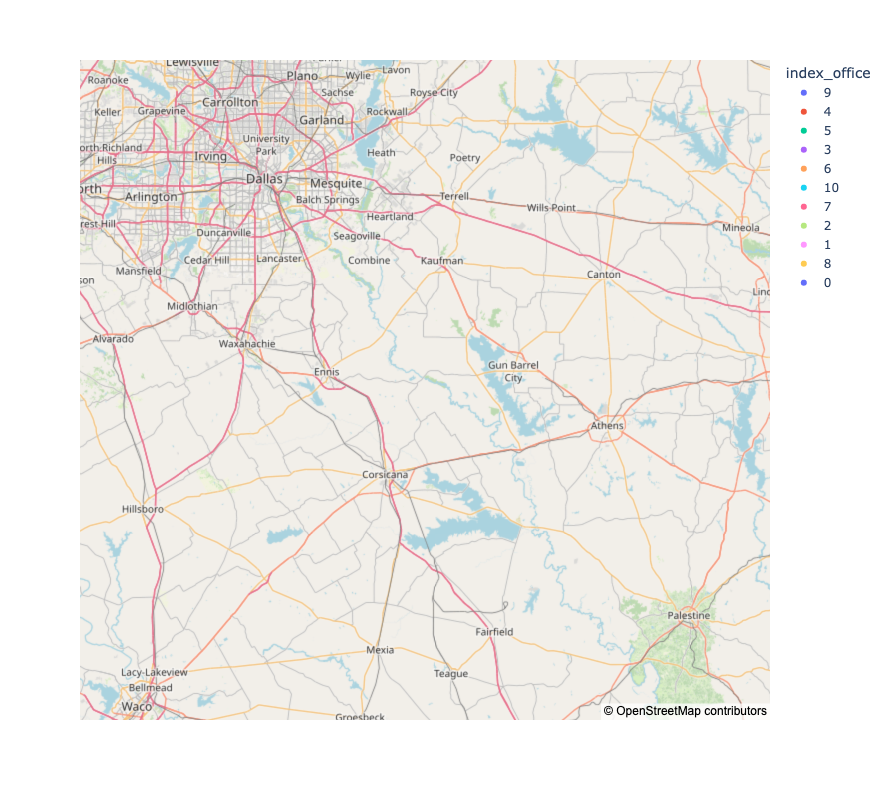

In [31]:
fig = px.scatter_mapbox(for_plot, 
                        lat="latitude", 
                        lon="longitude", 
                        color='index_office',
                        zoom=8, 
                        height=800,
                        width=800)

fig.update_layout(mapbox_style="open-street-map")
fig.show()